# Content Based Filtering (CBF) Model

In [32]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import random
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

In [2]:
product_data = pd.read_csv("product_info.csv",encoding="iso-8859-1")

In [3]:
product_data.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320.0,3.6364,11,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827.0,4.1538,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253.0,4.2500,16,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018.0,4.4762,21,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691.0,3.2308,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [4]:
product_data.isna().sum()

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1599
variation_desc        7243
ingredients            944
price_usd                2
value_price_usd       8043
sale_price_usd        8222
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        1
highlights            2206
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5742
dtype: int64

In [5]:
product_data.nunique()

product_id            8494
product_name          8415
brand_id               305
brand_name             305
loves_count           7436
rating                4394
reviews               1557
size                  2056
variation_type           8
variation_value       2729
variation_desc         936
ingredients           6540
price_usd              298
value_price_usd        174
sale_price_usd          89
limited_edition          2
new                      2
online_only              2
out_of_stock             2
sephora_exclusive        3
highlights            4418
primary_category        11
secondary_category      43
tertiary_category      119
child_count             55
child_max_price        222
child_min_price        208
dtype: int64

In [6]:
# List of file paths
file_paths = [
    "reviews_0-250_chunk_0.csv",
    "reviews_0-250_chunk_1.csv",
    "reviews_0-250_chunk_2.csv",
    "reviews_0-250_chunk_3.csv",
    "reviews_0-250_chunk_4.csv",
    "reviews_0-250_chunk_5.csv",
]

# Read and concatenate all files into a single DataFrame
reviews_data = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

In [7]:
reviews_data.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [8]:
reviews_data.isna().sum()

Unnamed: 0                       0
author_id                        0
rating                           0
is_recommended              117486
helpfulness                 331832
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                    999
review_title                167011
skin_tone                   106056
eye_color                   138488
skin_type                    74683
hair_color                  141081
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64

In [9]:
reviews_data.nunique()

Unnamed: 0                  602130
author_id                   378305
rating                           5
is_recommended                   2
helpfulness                   2314
total_feedback_count           551
total_neg_feedback_count       207
total_pos_feedback_count       484
submission_time               5317
review_text                 508467
review_title                202373
skin_tone                       14
eye_color                        6
skin_type                        4
hair_color                       7
product_id                     250
product_name                   249
brand_name                      60
price_usd                       92
dtype: int64

In [10]:
import nltk
import os

# Set the custom NLTK data path
nltk_data_path = '/Users/agrajatipare/Downloads/ML Project - Sephora/nltk_data'

# Make sure the directory exists
if not os.path.exists(nltk_data_path):
    os.makedirs(nltk_data_path)

# Add the custom path to NLTK's search paths
nltk.data.path.append(nltk_data_path)

# Download the required resources
nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/agrajatipare/Downloads/ML Project -
[nltk_data]     Sephora/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/agrajatipare/Downloads/ML Project -
[nltk_data]     Sephora/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/agrajatipare/Downloads/ML Project -
[nltk_data]     Sephora/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Preprocessing Product Data

In [11]:
# Handle missing values

# Product Name - Fill with empty string (no NA values)
product_data['product_name'] = product_data['product_name'].fillna('')

# Brand Name - Fill with 'Unknown' (no NA values)
product_data['brand_name'] = product_data['brand_name'].fillna('Unknown')

# Ingredients and Highlights - Fill with empty strings
product_data['ingredients'] = product_data['ingredients'].fillna('')
product_data['highlights'] = product_data['highlights'].fillna('')

# Categories - Fill with 'Unknown' (handle NA values)
product_data['primary_category'] = product_data['primary_category'].fillna('Unknown')
product_data['secondary_category'] = product_data['secondary_category'].fillna('Unknown')
product_data['tertiary_category'] = product_data['tertiary_category'].fillna('Unknown')

# Impute Price with Median Price Grouped by Tertiary Category
product_data['price_usd'] = product_data.groupby('tertiary_category')['price_usd'].transform(
    lambda x: x.fillna(x.median())
)

# Impute Rating with Median Rating Grouped by Tertiary Category
product_data['rating'] = product_data.groupby('tertiary_category')['rating'].transform(
    lambda x: x.fillna(x.median())
)

# Drop the row where rating is 315
product_data = product_data[product_data['rating'] != 315]

# Impute the missing value in 'sephora_exclusive' with 0
product_data['sephora_exclusive'] = product_data['sephora_exclusive'].fillna(0)

# Replace any values that are not '0' or '1' with 0
product_data['sephora_exclusive'] = product_data['sephora_exclusive'].apply(
    lambda x: 0 if str(x) not in ['0', '1'] else x
)

In [12]:
# Standardize boolean columns
bool_columns = ['limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive']
for col in bool_columns:
    product_data[col] = product_data[col].astype(int)

In [13]:
# Text cleaning function
def clean_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    
    # Simple tokenization by splitting on whitespace instead of using nltk.word_tokenize
    tokens = text.split()
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)
    
# Clean text columns
print("Cleaning text data...")
product_data['ingredients_cleaned'] = product_data['ingredients'].apply(clean_text)
product_data['highlights_cleaned'] = product_data['highlights'].apply(clean_text)
product_data['product_name_cleaned'] = product_data['product_name'].apply(lambda x: clean_text(str(x)))

Cleaning text data...


In [14]:
# Combine text features
# This combines all relevant textual information about the product into one field for feature extraction or vectorization.
product_data['combined_text'] = (
    product_data['product_name_cleaned'] + ' ' + 
    product_data['ingredients_cleaned'] + ' ' + 
    product_data['highlights_cleaned']
)

In [15]:
# Scale numerical features
scaler = MinMaxScaler()
product_data['price_scaled'] = scaler.fit_transform(product_data[['price_usd']])
product_data['rating_scaled'] = product_data['rating'] / 5.0  # Assuming 5-star rating system

In [16]:
product_data.head(10)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,tertiary_category,child_count,child_max_price,child_min_price,ingredients_cleaned,highlights_cleaned,product_name_cleaned,combined_text,price_scaled,rating_scaled
0,P473671,Fragrance Discovery Set,6342,19-69,6320.0,3.6364,11,NaN,NaN,NaN,...,Perfume Gift Sets,0,NaN,NaN,capri eau parfum alcohol denat alcohol parfum ...,unisex genderless scent warm spicy scent woody...,fragrance discovery set,fragrance discovery set capri eau parfum alcoh...,0.016869,0.72728
1,P473668,La Habana Eau de Parfum,6342,19-69,3827.0,4.1538,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,Perfume,2,85.0,30.0,alcohol denat alcohol parfum fragrance ethylhe...,unisex genderless scent layerable scent warm s...,habana eau parfum,habana eau parfum alcohol denat alcohol parfum...,0.101212,0.83076
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253.0,4.2500,16,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,Perfume,2,75.0,30.0,alcohol denat alcohol parfum fragrance limonen...,unisex genderless scent layerable scent woody ...,rainbow bar eau parfum,rainbow bar eau parfum alcohol denat alcohol p...,0.101212,0.85000
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018.0,4.4762,21,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,Perfume,2,75.0,30.0,alcohol denat alcohol parfum fragrance coumari...,unisex genderless scent layerable scent warm s...,kasbah eau parfum,kasbah eau parfum alcohol denat alcohol parfum...,0.101212,0.89524
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691.0,3.2308,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,Perfume,2,75.0,30.0,alcohol denat alcohol parfum fragrance octoxyn...,unisex genderless scent layerable scent woody ...,purple haze eau parfum,purple haze eau parfum alcohol denat alcohol p...,0.101212,0.64616
5,P473661,Kasbah Eau de Parfum Travel Spray,6342,19-69,2448.0,4.4762,21,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL Eau de Parfum Spray,...,Rollerballs & Travel Size,0,NaN,NaN,alcohol denat alcohol parfum fragrance coumari...,warm spicy scent unisex genderless scent layer...,kasbah eau parfum travel spray,kasbah eau parfum travel spray alcohol denat a...,0.014233,0.89524
6,P473659,Purple Haze Eau de Parfum Travel Spray,6342,19-69,1619.0,3.2308,13,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,Rollerballs & Travel Size,0,NaN,NaN,alcohol denat alcohol parfum fragrance octoxyn...,unisex genderless scent layerable scent woody ...,purple haze eau parfum travel spray,purple haze eau parfum travel spray alcohol de...,0.014233,0.64616
7,P473666,Invisible Post Eau de Parfum,6342,19-69,1542.0,3.6250,8,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,Perfume,2,75.0,30.0,alcohol denat alcohol parfum fragrance ethylhe...,unisex genderless scent allure best beauty awa...,invisible post eau parfum,invisible post eau parfum alcohol denat alcoho...,0.101212,0.72500
8,P472300,Capri Eau de Parfum,6342,19-69,1542.0,3.5714,7,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL Eau de Parfum Spray,...,Perfume,2,75.0,30.0,alcohol denat alcohol parfum fragrance limonen...,fresh scent layerable scent unisex genderless ...,capri eau parfum,capri eau parfum alcohol denat alcohol parfum ...,0.101212,0.71428
9,P473667,Invisible Post Eau de Parfum Travel Spray,6342,19-69,1377.0,3.6250,8,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,Rollerballs & Travel Size,0,NaN,NaN,alcohol denat alcohol parfum fragrance ethylhe...,unisex genderless scent allure best beauty awa...,invisible post eau parfum travel spray,invisible post eau parfum travel spray alcohol...,0.014233,0.72500


## Preprocessing Reviews Data

In [17]:
# Handle missing values
reviews_data['rating'] = reviews_data['rating'].fillna(0)
reviews_data['is_recommended'] = reviews_data['is_recommended'].fillna(0).astype(int)
reviews_data['skin_type'] = reviews_data['skin_type'].fillna('Unknown')
reviews_data['skin_tone'] = reviews_data['skin_tone'].fillna('Unknown')
reviews_data['hair_color'] = reviews_data['hair_color'].fillna('Unknown')
reviews_data['eye_color'] = reviews_data['eye_color'].fillna('Unknown')
reviews_data['review_text'] = reviews_data['review_text'].fillna('')

In [18]:
# Clean review text
reviews_data['review_text_cleaned'] = reviews_data['review_text'].apply(clean_text)

In [19]:
# Convert submission time to datetime if it's not already
if 'submission_time' in reviews_data.columns:
    reviews_data['submission_time'] = pd.to_datetime(reviews_data['submission_time'], errors='coerce')

In [20]:
# Aggregate reviews by product
print("Aggregating reviews by product...")
review_aggs = reviews_data.groupby('product_id').agg({
    'rating': 'mean',
    'is_recommended': 'mean',
    'total_feedback_count': 'sum',
    'total_pos_feedback_count': 'sum',
    'total_neg_feedback_count': 'sum',
    'review_text_cleaned': lambda x: ' '.join(x)
})

# Rename aggregated columns
review_aggs.columns = [
    'user_rating_avg',
    'recommendation_rate',
    'total_feedback',
    'total_positive_feedback',
    'total_negative_feedback',
    'all_reviews_text'
]

Aggregating reviews by product...


In [21]:
# Calculate review count per product
product_review_counts = reviews_data['product_id'].value_counts().to_frame()
product_review_counts.columns = ['review_count']
review_aggs = review_aggs.join(product_review_counts)

In [22]:
# Calculate weighted rating (Wilson score lower bound for 95% confidence)
# To reduce bias and improve the reliability of product ratings, especially in scenarios where some products have very few reviews.
def wilson_score(pos, n):
    if n == 0:
        return 0
    z = 1.96  # 95% confidence
    phat = pos / n
    return (phat + z*z/(2*n) - z*np.sqrt((phat*(1-phat)+z*z/(4*n))/n))/(1+z*z/n)

review_aggs['wilson_score'] = review_aggs.apply(
    lambda x: wilson_score(x['recommendation_rate'] * x['review_count'], x['review_count']), 
    axis=1
)

In [23]:
review_aggs.head()

,user_rating_avg,recommendation_rate,total_feedback,total_positive_feedback,total_negative_feedback,all_reviews_text,review_count,wilson_score
product_id,,,,,,,,
P114902,4.419882,0.212557,4202,3573,629,wanted try help texture skin well visible pore...,1529,0.192784
P12045,4.443391,0.524007,5260,4209,1051,sensitive red skin added skin routine morning ...,1687,0.500147
P122718,4.611715,0.176569,1827,1470,357,super nice neutral smell feel great face secon...,1195,0.155996
P122774,4.072171,0.083792,2683,2155,528,product caused allergic reaction little red bu...,1635,0.071317
P122882,4.381541,0.164244,1964,1538,426,product pretty good however product contains a...,1376,0.145608


## User Demographic Features

In [24]:
# Extract user demographic preferences per product
# Skin type preferences
skin_type_prefs = pd.crosstab(
    reviews_data['product_id'], 
    reviews_data['skin_type'], 
    normalize='index'
).add_prefix('skin_type_')

# Skin tone preferences
skin_tone_prefs = pd.crosstab(
    reviews_data['product_id'], 
    reviews_data['skin_tone'], 
    normalize='index'
).add_prefix('skin_tone_')

# Hair color preferences
hair_color_prefs = pd.crosstab(
    reviews_data['product_id'], 
    reviews_data['hair_color'], 
    normalize='index'
).add_prefix('hair_color_')

# Eye color preferences
eye_color_prefs = pd.crosstab(
    reviews_data['product_id'], 
    reviews_data['eye_color'], 
    normalize='index'
).add_prefix('eye_color_')

# Merge all demographic preferences
demographic_features = pd.concat(
    [skin_type_prefs, skin_tone_prefs, hair_color_prefs, eye_color_prefs], 
    axis=1
).fillna(0)

demographic_features.head()

,skin_type_Unknown,skin_type_combination,skin_type_dry,skin_type_normal,skin_type_oily,skin_tone_Unknown,skin_tone_dark,skin_tone_deep,skin_tone_ebony,skin_tone_fair,...,hair_color_brunette,hair_color_gray,hair_color_red,eye_color_Grey,eye_color_Unknown,eye_color_blue,eye_color_brown,eye_color_gray,eye_color_green,eye_color_hazel
product_id,,,,,,,,,,,,,,,,,,,,,
P114902,0.402224,0.343362,0.043165,0.048398,0.162852,0.402878,0.0,0.017659,0.0,0.143231,...,0.000000,0.002616,0.008502,0.001308,0.770438,0.047744,0.120340,0.0,0.032047,0.028123
P12045,0.318317,0.388263,0.150563,0.065797,0.077060,0.342620,0.0,0.014226,0.0,0.165382,...,0.002371,0.007706,0.016598,0.004742,0.434499,0.100771,0.328394,0.0,0.061055,0.070539
P122718,0.433473,0.333891,0.042678,0.040167,0.149791,0.405021,0.0,0.015063,0.0,0.128870,...,0.001674,0.003347,0.008368,0.000837,0.797490,0.042678,0.108787,0.0,0.030126,0.020084
P122774,0.307034,0.421407,0.078287,0.109480,0.083792,0.335168,0.0,0.007951,0.0,0.163914,...,0.000000,0.000612,0.003670,0.000000,0.893578,0.025688,0.048318,0.0,0.014679,0.017737
P122882,0.209302,0.522529,0.108285,0.114826,0.045058,0.330669,0.0,0.011628,0.0,0.156977,...,0.001453,0.002180,0.005087,0.001453,0.811773,0.035610,0.102471,0.0,0.027616,0.021076


In [25]:
demographic_features.iloc[10]

skin_type_Unknown        0.330641
skin_type_combination    0.362443
skin_type_dry            0.102978
skin_type_normal         0.127713
skin_type_oily           0.076224
skin_tone_Unknown        0.491166
skin_tone_dark           0.000000
skin_tone_deep           0.012620
skin_tone_ebony          0.000000
skin_tone_fair           0.111055
skin_tone_fairLight      0.009591
skin_tone_light          0.154972
skin_tone_lightMedium    0.122665
skin_tone_medium         0.013125
skin_tone_mediumTan      0.051994
skin_tone_notSureST      0.000000
skin_tone_olive          0.000000
skin_tone_porcelain      0.000000
skin_tone_rich           0.002019
skin_tone_tan            0.030793
hair_color_Unknown       0.870772
hair_color_auburn        0.004038
hair_color_black         0.032812
hair_color_blonde        0.017668
hair_color_brown         0.066633
hair_color_brunette      0.000000
hair_color_gray          0.001514
hair_color_red           0.006562
eye_color_Grey           0.000505
eye_color_Unkn

## Merged Dataset

In [26]:
# Merge product data with review aggregates
merged_data = pd.merge(
    product_data,
    review_aggs,
    left_on='product_id',
    right_index=True,
    how='left'
)

# Fill missing review data with defaults
merged_data['user_rating_avg'] = merged_data['user_rating_avg'].fillna(merged_data['rating'])
merged_data['recommendation_rate'] = merged_data['recommendation_rate'].fillna(0.5)
merged_data['review_count'] = merged_data['review_count'].fillna(0)
merged_data['wilson_score'] = merged_data['wilson_score'].fillna(0)
merged_data['all_reviews_text'] = merged_data['all_reviews_text'].fillna('')

# Add demographic features
merged_data = pd.merge(
    merged_data,
    demographic_features,
    left_on='product_id',
    right_index=True,
    how='left'
).fillna(0)

merged_data.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,hair_color_brunette,hair_color_gray,hair_color_red,eye_color_Grey,eye_color_Unknown,eye_color_blue,eye_color_brown,eye_color_gray,eye_color_green,eye_color_hazel
0,P473671,Fragrance Discovery Set,6342,19-69,6320.0,3.6364,11,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P473668,La Habana Eau de Parfum,6342,19-69,3827.0,4.1538,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253.0,4.2500,16,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018.0,4.4762,21,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691.0,3.2308,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Engineering

In [27]:
# 1. Handle primary_category (11 unique values)
# Standard one-hot encoding is fine for this small number
primary_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
primary_encoded = primary_encoder.fit_transform(product_data[['primary_category']])
primary_feature_names = [f'primary_{cat}' for cat in primary_encoder.categories_[0]]
primary_df = pd.DataFrame(
    primary_encoded,
    columns=primary_feature_names,
    index=product_data.index
)

# 2. Handle secondary_category (43 unique values)
# Standard one-hot encoding is still reasonable here
secondary_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
secondary_encoded = secondary_encoder.fit_transform(product_data[['secondary_category']])
secondary_feature_names = [f'secondary_{cat}' for cat in secondary_encoder.categories_[0]]
secondary_df = pd.DataFrame(
    secondary_encoded,
    columns=secondary_feature_names,
    index=product_data.index
)

# 3. Handle tertiary_category (119 unique values)
# Group less frequent categories into "Other"
tertiary_counts = product_data['tertiary_category'].value_counts()
top_tertiary = tertiary_counts[tertiary_counts >= 10].index  # Keep categories with at least 10 products
product_data['tertiary_category_grouped'] = product_data['tertiary_category'].apply(
    lambda x: x if x in top_tertiary else 'Other'
)

# One-hot encode the grouped tertiary categories
tertiary_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
tertiary_encoded = tertiary_encoder.fit_transform(product_data[['tertiary_category_grouped']])
tertiary_feature_names = [f'tertiary_{cat}' for cat in tertiary_encoder.categories_[0]]
tertiary_df = pd.DataFrame(
    tertiary_encoded,
    columns=tertiary_feature_names,
    index=product_data.index
)

# 4. Handle brand_name (305 unique values)
# Keep only top brands, group others as "Other"
brand_counts = product_data['brand_name'].value_counts()
top_brands = brand_counts[brand_counts >= 10].index  # Keep brands with at least 10 products
product_data['brand_name_grouped'] = product_data['brand_name'].apply(
    lambda x: x if x in top_brands else 'Other'
)

# One-hot encode the grouped brands
brand_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
brand_encoded = brand_encoder.fit_transform(product_data[['brand_name_grouped']])
brand_feature_names = [f'brand_{brand}' for brand in brand_encoder.categories_[0]]
brand_df = pd.DataFrame(
    brand_encoded,
    columns=brand_feature_names,
    index=product_data.index
)

# Print category reduction summary
print(f"Primary categories: {len(primary_encoder.categories_[0])} (original: 11)")
print(f"Secondary categories: {len(secondary_encoder.categories_[0])} (original: 43)")
print(f"Tertiary categories: {len(tertiary_encoder.categories_[0])} (original: 119, reduced)")
print(f"Brands: {len(brand_encoder.categories_[0])} (original: 305, reduced)")


Primary categories: 10 (original: 11)
Secondary categories: 43 (original: 43)
Tertiary categories: 94 (original: 119, reduced)
Brands: 226 (original: 305, reduced)


In [28]:
# 1. TF-IDF for text data
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(merged_data['combined_text'])
tfidf_feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_feature_names,
    index=merged_data.index
)

# 2. Numerical features
numerical_features = merged_data[[
    'price_scaled', 
    'rating_scaled', 
    'user_rating_avg', 
    'recommendation_rate',
    'wilson_score',
    'review_count'
]].copy()

# Scale review count (log transformation to handle skewness)
numerical_features['review_count_scaled'] = np.log1p(numerical_features['review_count'])
numerical_features = numerical_features.fillna(0)

# 3. Boolean features
boolean_features = merged_data[bool_columns].copy()

In [29]:
# Combine all feature matrices
print("Combining all features...")
all_features = [
    tfidf_df,              # Text features
    brand_df,              # Brand features
    primary_df,            # Primary category
    secondary_df,          # Secondary category
    tertiary_df,           # Tertiary category
    numerical_features,    # Numerical features
    boolean_features       # Boolean features
]

# Add demographic features if they exist
if not demographic_features.empty:
    # Reindex to match merged_data
    demo_df = demographic_features.reindex(merged_data.index).fillna(0)
    all_features.append(demo_df)

# Concatenate all features
feature_matrix = pd.concat(all_features, axis=1)
print(f"Final feature matrix shape: {feature_matrix.shape}")

# Save preprocessed data
merged_data.to_csv('preprocessed_beauty_data.csv', index=False)
feature_matrix.to_csv('beauty_feature_matrix.csv')
print("Preprocessing complete! Data saved to CSV files.")

# Print feature breakdown
feature_counts = {
    'Text TF-IDF features': tfidf_df.shape[1],
    'Brand features': brand_df.shape[1],
    'Primary category features': primary_df.shape[1],
    'Secondary category features': secondary_df.shape[1],
    'Tertiary category features': tertiary_df.shape[1],
    'Numerical features': numerical_features.shape[1],
    'Boolean features': boolean_features.shape[1],
    'Demographic features': demographic_features.shape[1] if not demographic_features.empty else 0
}

print("\nFeature breakdown:")
for feature_type, count in feature_counts.items():
    print(f"  {feature_type}: {count}")
print(f"Total features: {feature_matrix.shape[1]}")

Combining all features...
Final feature matrix shape: (8493, 1420)
Preprocessing complete! Data saved to CSV files.

Feature breakdown:
  Text TF-IDF features: 1000
  Brand features: 226
  Primary category features: 10
  Secondary category features: 43
  Tertiary category features: 94
  Numerical features: 7
  Boolean features: 5
  Demographic features: 35
Total features: 1420


With **8,493** products and **1,420** features, we have a well-structured representation for content-based filtering.
The feature breakdown shows a good balance:

**Text TF-IDF features (1000)**: This forms the backbone of the content-based system, capturing important terms from product descriptions, ingredients, and highlights.

**Categorical features (373 total)**:

Brand features (226)
Primary category (10)
Secondary category (43)
Tertiary category (94)

These create clear separations between different product types and brands, which is crucial for accurate recommendations.

**Numerical and boolean features (12 total)**:

Numerical features (7): These capture product ratings, price, and review metrics
Boolean features (5): These indicate special product attributes (limited edition, new, etc.)


**Demographic features (35)**: These capture different user preferences by skin type, tone, etc., which will help personalize recommendations.

### We have more positive feedbacks than negative feedbacks, to handle class imbalance -

===== CONTENT-BASED FILTERING FOR BEAUTY PRODUCTS =====
Loading preprocessed data...
Loaded 8493 products with 1420 features
Loaded 602130 reviews
Using similarity threshold: 0.7

Feedback class distribution:
Positive feedback: 406094 (67.44%)
Negative feedback: 196036 (32.56%)
Negative feedback weight: 2.07x

Calculating cosine similarity matrix...
Similarity matrix shape: (8493, 8493)

Sample product: Fragrance Discovery Set (ID: P473671)
Found 7770 products above similarity threshold 0.7

Top 5 recommendations:
1. Fully Booked Rollerball Perfume Gift set (Brand: Ellis Brooklyn) - Similarity: 0.9329
2. Perfume Sampler Set (Brand: Bon Parfumeur) - Similarity: 0.9320
3. Exploration Set (Brand: Commodity) - Similarity: 0.9269
4. Fragrance Discovery Set (Brand: By Rosie Jane) - Similarity: 0.9206
5. Alien Goddess Eau de Parfum Perfume Set (Brand: Mugler) - Similarity: 0.9196

Explanation: Fully Booked Rollerball Perfume Gift set is very similar to Fragrance Discovery Set because both bel

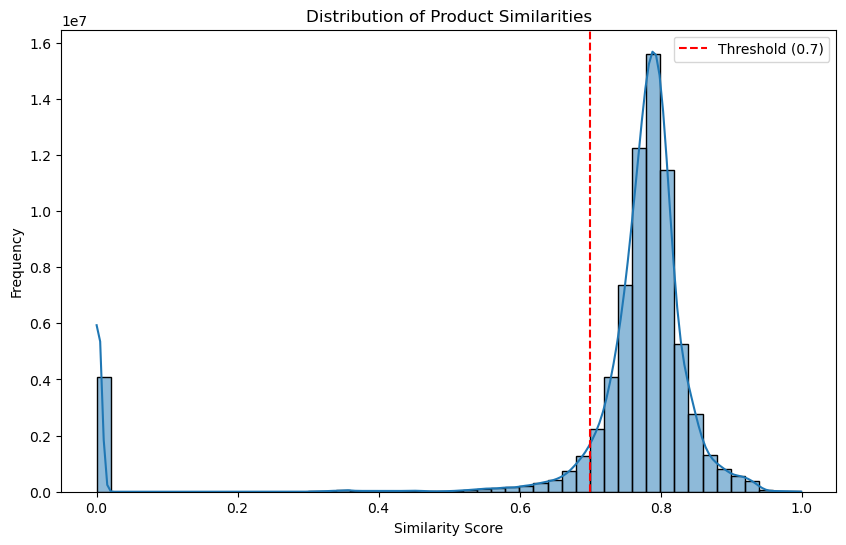

In [30]:
# Start timing
start_time = time.time()

print("===== CONTENT-BASED FILTERING FOR BEAUTY PRODUCTS =====")
print("Loading preprocessed data...")

# Load preprocessed data
feature_matrix = pd.read_csv('beauty_feature_matrix.csv', index_col=0)
merged_data = pd.read_csv('preprocessed_beauty_data.csv')

print(f"Loaded {len(merged_data)} products with {feature_matrix.shape[1]} features")
print(f"Loaded {len(reviews_data)} reviews")

# Set the similarity threshold based on distribution analysis
similarity_threshold = 0.7  # Adjust based on your similarity distribution
print(f"Using similarity threshold: {similarity_threshold}")

# Check for class imbalance in feedback
if 'is_recommended' in reviews_data.columns:
    positive_count = reviews_data['is_recommended'].sum()
    total_count = len(reviews_data)
    negative_count = total_count - positive_count

    print(f"\nFeedback class distribution:")
    print(f"Positive feedback: {positive_count} ({positive_count/total_count*100:.2f}%)")
    print(f"Negative feedback: {negative_count} ({negative_count/total_count*100:.2f}%)")

    # Calculate weights for handling class imbalance
    pos_weight = 1.0
    neg_weight = positive_count / negative_count if negative_count > 0 else 1.0
    print(f"Negative feedback weight: {neg_weight:.2f}x")

# Create product ID to index mapping
product_id_to_idx = {pid: idx for idx, pid in enumerate(merged_data['product_id'])}
idx_to_product_id = {idx: pid for idx, pid in enumerate(merged_data['product_id'])}

# Calculate similarity matrix
print("\nCalculating cosine similarity matrix...")
similarity_matrix = cosine_similarity(feature_matrix)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

# Save similarity matrix for future use
np.save('beauty_similarity_matrix.npy', similarity_matrix)

# Get a sample product for demonstration
sample_idx = 0
sample_product_id = merged_data['product_id'].iloc[sample_idx]
sample_product_name = merged_data['product_name'].iloc[sample_idx]
print(f"\nSample product: {sample_product_name} (ID: {sample_product_id})")

# Get similarity scores for this product
similarity_scores = similarity_matrix[sample_idx]

# Convert to Series for easier manipulation
similarity_scores = pd.Series(similarity_scores, index=merged_data['product_id'])

# Sort by similarity (descending)
similarity_scores = similarity_scores.sort_values(ascending=False)

# Remove the product itself
similarity_scores = similarity_scores.drop(sample_product_id, errors='ignore')

# Add a similarity threshold to filter out less similar products
filtered_scores = similarity_scores[similarity_scores >= similarity_threshold]

# Check if we have any recommendations above threshold
if len(filtered_scores) < 5:
    print(f"Few products above similarity threshold {similarity_threshold}. Using lower threshold.")
    lower_threshold = 0.5
    filtered_scores = similarity_scores[similarity_scores >= lower_threshold]
    # If still not enough, use the original
    if len(filtered_scores) < 5:
        filtered_scores = similarity_scores
else:
    print(f"Found {len(filtered_scores)} products above similarity threshold {similarity_threshold}")

# Get top 5 most similar products
top_5_ids = filtered_scores.head(5).index

# Get details for these products
top_5_products = merged_data[merged_data['product_id'].isin(top_5_ids)].copy()

# Add similarity scores
top_5_products['similarity_score'] = top_5_products['product_id'].map(filtered_scores)

# Sort by similarity score
top_5_products = top_5_products.sort_values('similarity_score', ascending=False)

# Display recommendations
print("\nTop 5 recommendations:")
for i, (_, product) in enumerate(top_5_products.iterrows()):
    print(f"{i+1}. {product['product_name']} (Brand: {product['brand_name']}) - Similarity: {product['similarity_score']:.4f}")

# Explain the top recommendation
top_rec_id = top_5_products['product_id'].iloc[0]
top_rec_idx = product_id_to_idx[top_rec_id]
top_rec_similarity = similarity_matrix[sample_idx, top_rec_idx]

# Get product details
source_product = merged_data.iloc[sample_idx]
rec_product = merged_data[merged_data['product_id'] == top_rec_id].iloc[0]

# Check for categorical matches
same_brand = source_product['brand_name'] == rec_product['brand_name']
same_primary = source_product['primary_category'] == rec_product['primary_category']
same_secondary = False
if 'secondary_category' in source_product and 'secondary_category' in rec_product:
    same_secondary = source_product['secondary_category'] == rec_product['secondary_category']

# Generate explanation
reasons = []
if same_brand:
    reasons.append(f"both are from the same brand ({source_product['brand_name']})")
if same_primary:
    reasons.append(f"both belong to the same product category ({source_product['primary_category']})")
if same_secondary:
    reasons.append(f"both belong to the same sub-category ({source_product['secondary_category']})")

if top_rec_similarity > 0.8:
    strength = "very similar"
elif top_rec_similarity > 0.6:
    strength = "quite similar"
elif top_rec_similarity > 0.4:
    strength = "somewhat similar"
else:
    strength = "slightly similar"

if reasons:
    explanation = f"{rec_product['product_name']} is {strength} to {source_product['product_name']} because {' and '.join(reasons)}."
else:
    explanation = f"{rec_product['product_name']} is {strength} to {source_product['product_name']} based on overall product features."

print(f"\nExplanation: {explanation}")

# Visualize similarity distribution
print("\nCreating similarity distribution visualization...")
plt.figure(figsize=(10, 6))
flat_similarities = similarity_matrix.flatten()
flat_similarities = flat_similarities[flat_similarities < 0.999]  # Remove self-similarities
sns.histplot(flat_similarities, bins=50, kde=True)
plt.title('Distribution of Product Similarities')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold ({similarity_threshold})')
plt.legend()
plt.show()


===== SIMPLIFIED EVALUATION METRICS =====
Using 100 samples for quick evaluation

1. Simplified Attribute Prediction
Standard Brand Accuracy: 80.00%
Threshold Brand Accuracy: 80.00%
Standard Category Accuracy: 99.00%
Threshold Category Accuracy: 99.00%

2. Simplified Catalog Coverage
Standard Coverage: 10.48%
Threshold Coverage: 10.48%

===== EVALUATION SUMMARY =====
Similarity Threshold: 0.7

Attribute Prediction:
  Brand Accuracy: 80.00% → 80.00% with threshold
  Category Accuracy: 99.00% → 99.00% with threshold

Catalog Coverage:
  Standard: 10.48% of catalog
  With Threshold: 10.48% of catalog


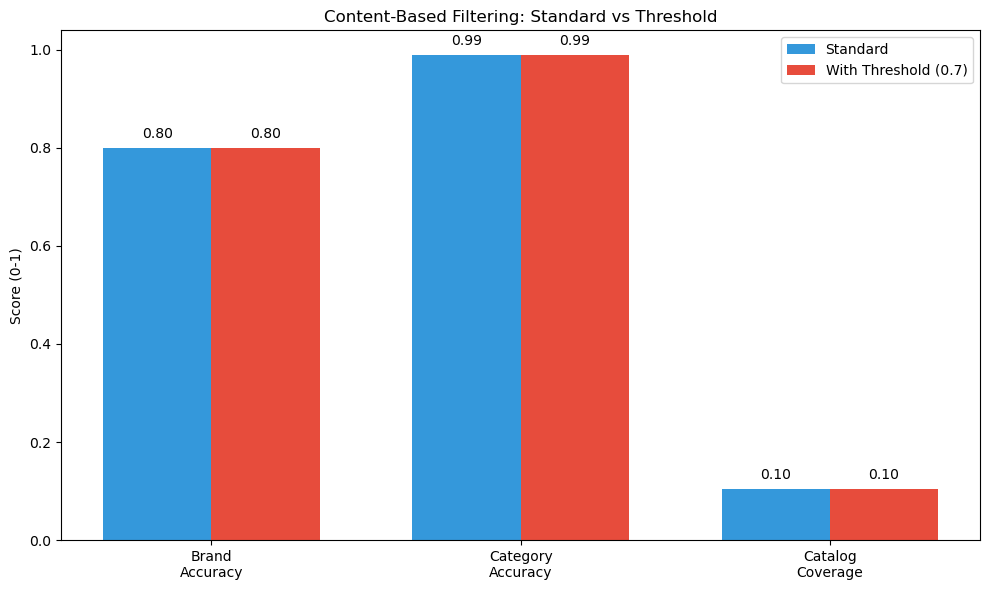


Total execution time: 1402.29 seconds (23.37 minutes)

Simplified content-based filtering evaluation complete!


In [34]:
# Continue from your existing code

print("\n===== SIMPLIFIED EVALUATION METRICS =====")

# Function to get recommendations (uses your existing variables)
def get_recommendations(product_id, n=5, apply_threshold=True):
    """Get recommendations for a product with optional threshold"""
    # Check if product exists
    if product_id not in product_id_to_idx:
        print(f"Product ID {product_id} not found")
        return None
    
    # Get product index and similarity scores
    idx = product_id_to_idx[product_id]
    sim_scores = similarity_matrix[idx]
    
    # Convert to Series for easier manipulation
    sim_scores = pd.Series(sim_scores, index=merged_data['product_id'])
    
    # Sort by similarity (descending)
    sim_scores = sim_scores.sort_values(ascending=False)
    
    # Remove the product itself
    sim_scores = sim_scores.drop(product_id, errors='ignore')
    
    # Apply threshold if requested
    if apply_threshold:
        filtered_scores = sim_scores[sim_scores >= similarity_threshold]
        # If too few results, fall back to unfiltered
        if len(filtered_scores) < n:
            filtered_scores = sim_scores
        sim_scores = filtered_scores
    
    # Get top n recommendations
    top_n_ids = sim_scores.head(n).index
    top_n_products = merged_data[merged_data['product_id'].isin(top_n_ids)].copy()
    
    # Add similarity scores
    top_n_products['similarity_score'] = top_n_products['product_id'].map(sim_scores)
    
    # Sort by similarity
    return top_n_products.sort_values('similarity_score', ascending=False)

# Sample size for evaluations (smaller = faster)
import random
evaluation_sample_size = 100
print(f"Using {evaluation_sample_size} samples for quick evaluation")

#===========================================
# 1. ATTRIBUTE PREDICTION (SIMPLIFIED)
#===========================================
print("\n1. Simplified Attribute Prediction")

# Randomly sample products for testing
random.seed(42)
test_products = random.sample(list(product_id_to_idx.keys()), evaluation_sample_size)

# Count correct predictions
standard_brand_correct = 0
threshold_brand_correct = 0
standard_category_correct = 0
threshold_category_correct = 0

for test_id in test_products:
    # Get the test product
    test_product_rows = merged_data[merged_data['product_id'] == test_id]
    if len(test_product_rows) == 0:
        continue
    test_product = test_product_rows.iloc[0]
    
    # Get true attributes
    true_brand = test_product['brand_name']
    if 'primary_category' in test_product:
        true_category = test_product['primary_category']
    else:
        continue  # Skip if no category information
    
    # Get recommendations without threshold
    standard_recs = get_recommendations(test_id, n=5, apply_threshold=False)
    if standard_recs is None or len(standard_recs) == 0:
        continue
        
    # Predict using most common attributes in recommendations
    pred_brand = standard_recs['brand_name'].value_counts().index[0]
    if 'primary_category' in standard_recs.columns:
        pred_category = standard_recs['primary_category'].value_counts().index[0]
        # Check if correct
        if pred_category == true_category:
            standard_category_correct += 1
    
    # Check if brand is correct
    if pred_brand == true_brand:
        standard_brand_correct += 1
    
    # Get recommendations with threshold
    threshold_recs = get_recommendations(test_id, n=5, apply_threshold=True)
    if threshold_recs is None or len(threshold_recs) == 0:
        continue
        
    # Predict using most common attributes in threshold recommendations
    pred_brand = threshold_recs['brand_name'].value_counts().index[0]
    if 'primary_category' in threshold_recs.columns:
        pred_category = threshold_recs['primary_category'].value_counts().index[0]
        # Check if correct
        if pred_category == true_category:
            threshold_category_correct += 1
    
    # Check if brand is correct
    if pred_brand == true_brand:
        threshold_brand_correct += 1

# Calculate accuracies
valid_count = len(test_products)
standard_brand_accuracy = standard_brand_correct / valid_count * 100
standard_category_accuracy = standard_category_correct / valid_count * 100
threshold_brand_accuracy = threshold_brand_correct / valid_count * 100
threshold_category_accuracy = threshold_category_correct / valid_count * 100

print(f"Standard Brand Accuracy: {standard_brand_accuracy:.2f}%")
print(f"Threshold Brand Accuracy: {threshold_brand_accuracy:.2f}%")
print(f"Standard Category Accuracy: {standard_category_accuracy:.2f}%")
print(f"Threshold Category Accuracy: {threshold_category_accuracy:.2f}%")

#===========================================
# 2. CATALOG COVERAGE (SIMPLIFIED)
#===========================================
print("\n2. Simplified Catalog Coverage")

# Sample products for catalog coverage evaluation
sampled_products = random.sample(list(product_id_to_idx.keys()), evaluation_sample_size)

# Track recommendations
standard_recommendations = set()
threshold_recommendations = set()
k = 10  # number of recommendations to track

for product_id in sampled_products:
    # Get standard recommendations
    standard_recs = get_recommendations(product_id, n=k, apply_threshold=False)
    if standard_recs is not None and not standard_recs.empty:
        standard_recommendations.update(standard_recs['product_id'].values)
    
    # Get threshold recommendations
    threshold_recs = get_recommendations(product_id, n=k, apply_threshold=True)
    if threshold_recs is not None and not threshold_recs.empty:
        threshold_recommendations.update(threshold_recs['product_id'].values)

# Calculate coverage
standard_coverage = len(standard_recommendations) / len(merged_data) * 100
threshold_coverage = len(threshold_recommendations) / len(merged_data) * 100

print(f"Standard Coverage: {standard_coverage:.2f}%")
print(f"Threshold Coverage: {threshold_coverage:.2f}%")

#===========================================
# EVALUATION SUMMARY
#===========================================
print("\n===== EVALUATION SUMMARY =====")
print(f"Similarity Threshold: {similarity_threshold}")
print("\nAttribute Prediction:")
print(f"  Brand Accuracy: {standard_brand_accuracy:.2f}% → {threshold_brand_accuracy:.2f}% with threshold")
print(f"  Category Accuracy: {standard_category_accuracy:.2f}% → {threshold_category_accuracy:.2f}% with threshold")
print("\nCatalog Coverage:")
print(f"  Standard: {standard_coverage:.2f}% of catalog")
print(f"  With Threshold: {threshold_coverage:.2f}% of catalog")

# Create summary visualization
plt.figure(figsize=(10, 6))
metrics = ['Brand\nAccuracy', 'Category\nAccuracy', 'Catalog\nCoverage']
standard_values = [standard_brand_accuracy/100, standard_category_accuracy/100, standard_coverage/100]
threshold_values = [threshold_brand_accuracy/100, threshold_category_accuracy/100, threshold_coverage/100]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, standard_values, width, label='Standard', color='#3498db')
plt.bar(x + width/2, threshold_values, width, label=f'With Threshold ({similarity_threshold})', color='#e74c3c')

plt.ylabel('Score (0-1)')
plt.title('Content-Based Filtering: Standard vs Threshold')
plt.xticks(x, metrics)
plt.legend()

for i, v in enumerate(standard_values):
    plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')
for i, v in enumerate(threshold_values):
    plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig('simplified_evaluation.png')
plt.show()

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal execution time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("\nSimplified content-based filtering evaluation complete!")